# Dividend Growth L/S — Research Notebook
**Signal**: 0.4 × Trailing-12M Yield Rank + 0.6 × YoY Dividend Growth Rank  
**Universe**: SP500 dividend payers only  
**Strategy**: Top-50 Long / Bottom-20 Short, weekly rebalance, dollar-neutral  
**DSL file**: `btest/strategies/dividend_growth_ls.py`  
**Signal builder**: `btest/scripts/build_div_signals.py`

---
Run cells top-to-bottom. Each section is self-contained.

In [2]:
import sys, pathlib, os

# Walk up from notebook location until we find the btest root (has 'strategies/' dir)
ROOT = pathlib.Path.cwd()
for p in [ROOT] + list(ROOT.parents):
    if (p / 'strategies').exists() and (p / 'equities').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)
print(f'Working dir: {ROOT}')

Working dir: c:\Personal\Business & Investments\Python codes\btest


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
print('Libraries loaded.')

Libraries loaded.


---
## 1 — Load Data

In [ ]:
# ── Paths (all relative to btest/ root) ──────────────────────────────────────
ATTEMPT = "research/Dividend Growth/001_baseline"

# Price data
prices_long = pd.read_parquet('equities/sp500_daily')
prices_long['date'] = pd.to_datetime(prices_long['date']).dt.tz_localize(None)
close = (
    prices_long[['date','ticker','close']]
    .set_index(['date','ticker'])['close']
    .unstack('ticker')
)

# Composite signal
composite = pd.read_parquet(f'{ATTEMPT}/data/div_composite.parquet')

# Backtest outputs
eq  = pd.read_parquet(f'{ATTEMPT}/outputs/equity.parquet')
pos = pd.read_parquet(f'{ATTEMPT}/outputs/positions.parquet')
wts = pd.read_parquet(f'{ATTEMPT}/outputs/weights.parquet')

# Active trading period
start_trade = eq[eq['leverage'] > 0].index[0]
end_trade   = eq.index[-1]
print(f'Price data   : {close.index.min().date()} → {close.index.max().date()}  ({close.shape[1]} tickers)')
print(f'Composite    : {composite.index.min().date()} → {composite.index.max().date()}  ({composite.notna().sum(axis=1).mean():.0f} avg payers/day)')
print(f'Trading live : {start_trade.date()} → {end_trade.date()}')

Price data   : 2015-01-02 → 2024-12-31  (453 tickers)
Composite    : 2015-01-02 → 2024-12-31  (109 avg payers/day)
Trading live : 2020-10-01 → 2024-12-31


---
## 2 — Signal Coverage & Distribution

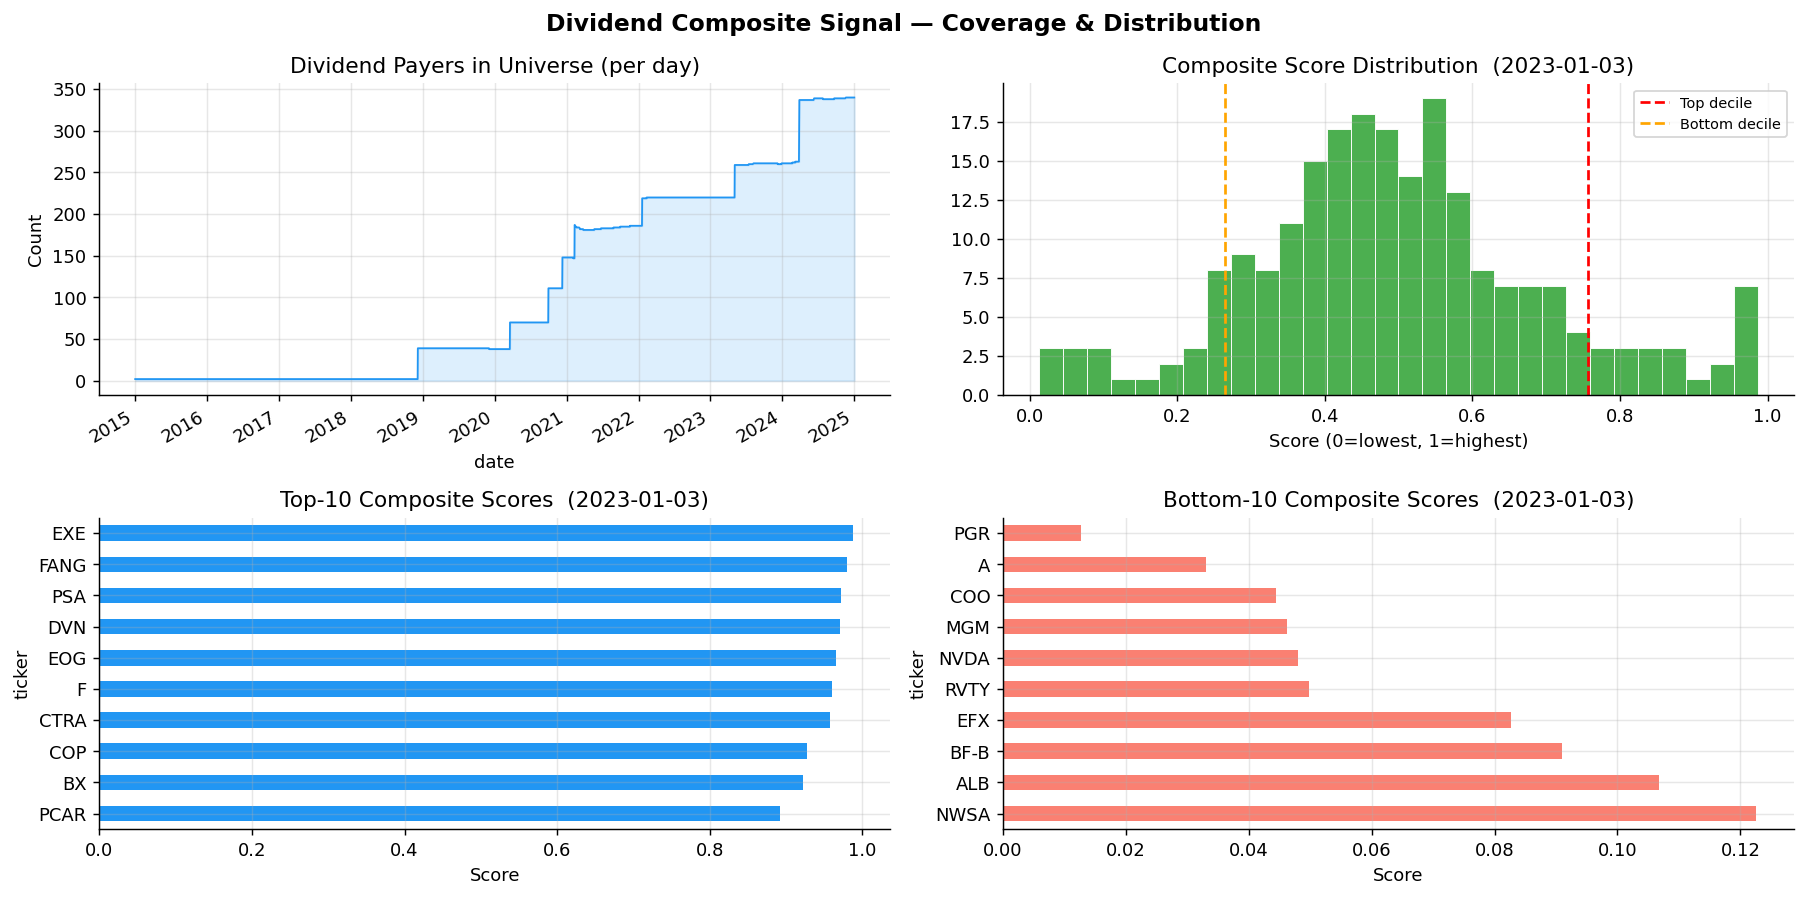

In [5]:
# Payers per day over time
payers_per_day = composite.notna().sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Dividend Composite Signal — Coverage & Distribution', fontsize=13, fontweight='bold')

# (0,0) Payers per day
ax = axes[0, 0]
payers_per_day.plot(ax=ax, color='#2196F3', linewidth=1)
ax.set_title('Dividend Payers in Universe (per day)')
ax.set_ylabel('Count')
ax.fill_between(payers_per_day.index, payers_per_day.values, alpha=0.15, color='#2196F3')

# (0,1) Composite score distribution on a recent date
ax = axes[0, 1]
sample_date = composite.loc[composite.index >= '2023-01-01'].index[0]
sample_row = composite.loc[sample_date].dropna()
ax.hist(sample_row.values, bins=30, color='#4CAF50', edgecolor='white', linewidth=0.5)
ax.axvline(sample_row.quantile(0.9), color='red', linestyle='--', label='Top decile')
ax.axvline(sample_row.quantile(0.1), color='orange', linestyle='--', label='Bottom decile')
ax.set_title(f'Composite Score Distribution  ({sample_date.date()})')
ax.set_xlabel('Score (0=lowest, 1=highest)')
ax.legend(fontsize=8)

# (1,0) Top-10 names on a recent date
ax = axes[1, 0]
top10 = sample_row.nlargest(10)
top10.plot(kind='barh', ax=ax, color='#2196F3')
ax.set_title(f'Top-10 Composite Scores  ({sample_date.date()})')
ax.set_xlabel('Score')
ax.invert_yaxis()

# (1,1) Bottom-10 names
ax = axes[1, 1]
bot10 = sample_row.nsmallest(10)
bot10.plot(kind='barh', ax=ax, color='salmon')
ax.set_title(f'Bottom-10 Composite Scores  ({sample_date.date()})')
ax.set_xlabel('Score')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 3 — Quintile Returns (Signal IC Analysis)

In [6]:
# Quintile spread: do high-composite names outperform low-composite?
# Use monthly rebalance for clarity

# Align composite and returns to the active period
comp_active  = composite.loc[(composite.index >= start_trade) & (composite.index <= end_trade)]
close_active = close.loc[(close.index >= start_trade) & (close.index <= end_trade)]

# Forward 1-month return (21 bars)
fwd_ret = close_active.pct_change(21).shift(-21)   # forward-looking (for IC only, not trading)

# Assign quintile on rebalance days (first trading day of each month)
monthly_dates = comp_active.resample('ME').last().index
monthly_dates = comp_active.index[comp_active.index.isin(comp_active.resample('ME').last().reindex(monthly_dates, method='ffill').index)]

quintile_rets = {q: [] for q in range(1, 6)}
ics = []

for dt in comp_active.index[::21]:   # every ~month
    if dt not in fwd_ret.index:
        continue
    scores = comp_active.loc[dt].dropna()
    fwd    = fwd_ret.loc[dt].reindex(scores.index).dropna()
    common = scores.index.intersection(fwd.index)
    if len(common) < 20:
        continue
    s, f = scores[common], fwd[common]
    # IC
    ic = s.corr(f, method='spearman')
    ics.append({'date': dt, 'ic': ic})
    # Quintile assignment
    q = pd.qcut(s, 5, labels=False) + 1
    for qi in range(1, 6):
        mean_ret = f[q == qi].mean()
        quintile_rets[qi].append({'date': dt, 'ret': mean_ret})

ic_series = pd.DataFrame(ics).set_index('date')['ic']
q_series  = {qi: pd.DataFrame(quintile_rets[qi]).set_index('date')['ret'] for qi in range(1, 6)}

print(f'IC mean:   {ic_series.mean():.4f}')
print(f'IC std:    {ic_series.std():.4f}')
print(f'ICIR:      {ic_series.mean()/ic_series.std():.3f}')
print(f'IC > 0:    {(ic_series > 0).mean():.1%}')

IC mean:   0.0073
IC std:    0.1133
ICIR:      0.064
IC > 0:    50.0%


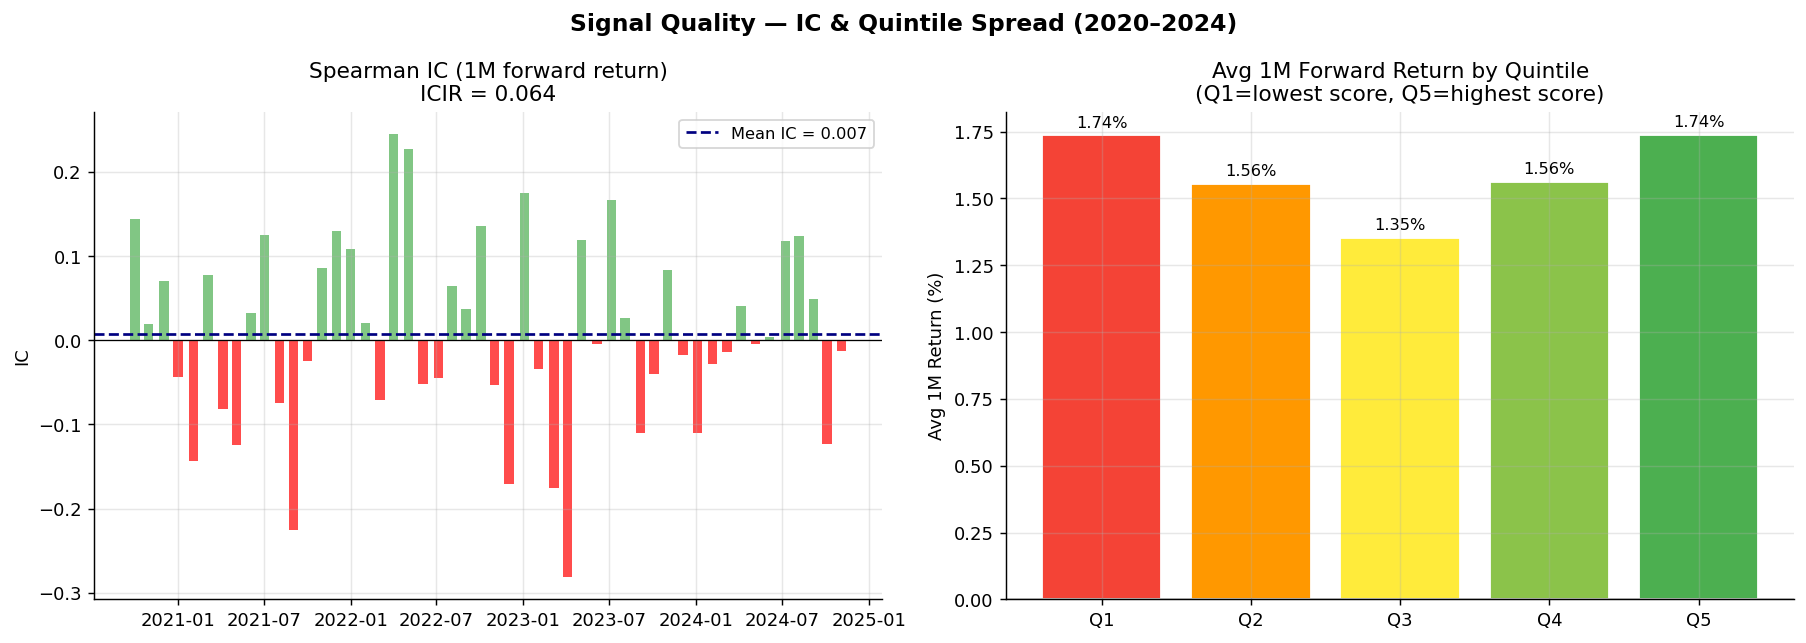

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Signal Quality — IC & Quintile Spread (2020–2024)', fontsize=13, fontweight='bold')

# IC bar chart
ax = axes[0]
colors = ['#4CAF50' if v >= 0 else 'red' for v in ic_series.values]
ax.bar(ic_series.index, ic_series.values, color=colors, alpha=0.7, width=20)
ax.axhline(ic_series.mean(), color='navy', linewidth=1.5, linestyle='--',
           label=f'Mean IC = {ic_series.mean():.3f}')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title(f'Spearman IC (1M forward return)\nICIR = {ic_series.mean()/ic_series.std():.3f}')
ax.set_ylabel('IC')
ax.legend(fontsize=9)

# Quintile mean returns
ax = axes[1]
q_means = [q_series[qi].mean() * 100 for qi in range(1, 6)]
bar_colors = ['#f44336','#ff9800','#ffeb3b','#8bc34a','#4CAF50']
bars = ax.bar([f'Q{i}' for i in range(1, 6)], q_means, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, q_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('Avg 1M Forward Return by Quintile\n(Q1=lowest score, Q5=highest score)')
ax.set_ylabel('Avg 1M Return (%)')

plt.tight_layout()
plt.show()

---
## 4 — Equity Curve & Performance

In [8]:
active_eq = eq.loc[eq.index >= start_trade].copy()
nav = active_eq['equity'] / active_eq['equity'].iloc[0]
roll_max = nav.cummax()
dd = (nav - roll_max) / roll_max

daily_ret  = active_eq['returns']
ann_ret    = (1 + daily_ret).prod() ** (252 / len(daily_ret)) - 1
ann_vol    = daily_ret.std() * np.sqrt(252)
sharpe     = ann_ret / ann_vol if ann_vol > 0 else 0
max_dd     = dd.min()
calmar     = ann_ret / abs(max_dd) if max_dd != 0 else 0
win_rate   = (daily_ret[daily_ret != 0] > 0).mean()

print('=== Performance Summary (active period) ===')
print(f'  Period   : {start_trade.date()} → {end_trade.date()}')
print(f'  CAGR     : {ann_ret:.2%}')
print(f'  Volatility: {ann_vol:.2%}')
print(f'  Sharpe   : {sharpe:.2f}')
print(f'  Max DD   : {max_dd:.2%}')
print(f'  Calmar   : {calmar:.2f}')
print(f'  Win rate : {win_rate:.1%}')

=== Performance Summary (active period) ===
  Period   : 2020-10-01 → 2024-12-31
  CAGR     : -0.05%
  Volatility: 8.51%
  Sharpe   : -0.01
  Max DD   : -12.28%
  Calmar   : -0.00
  Win rate : 49.3%


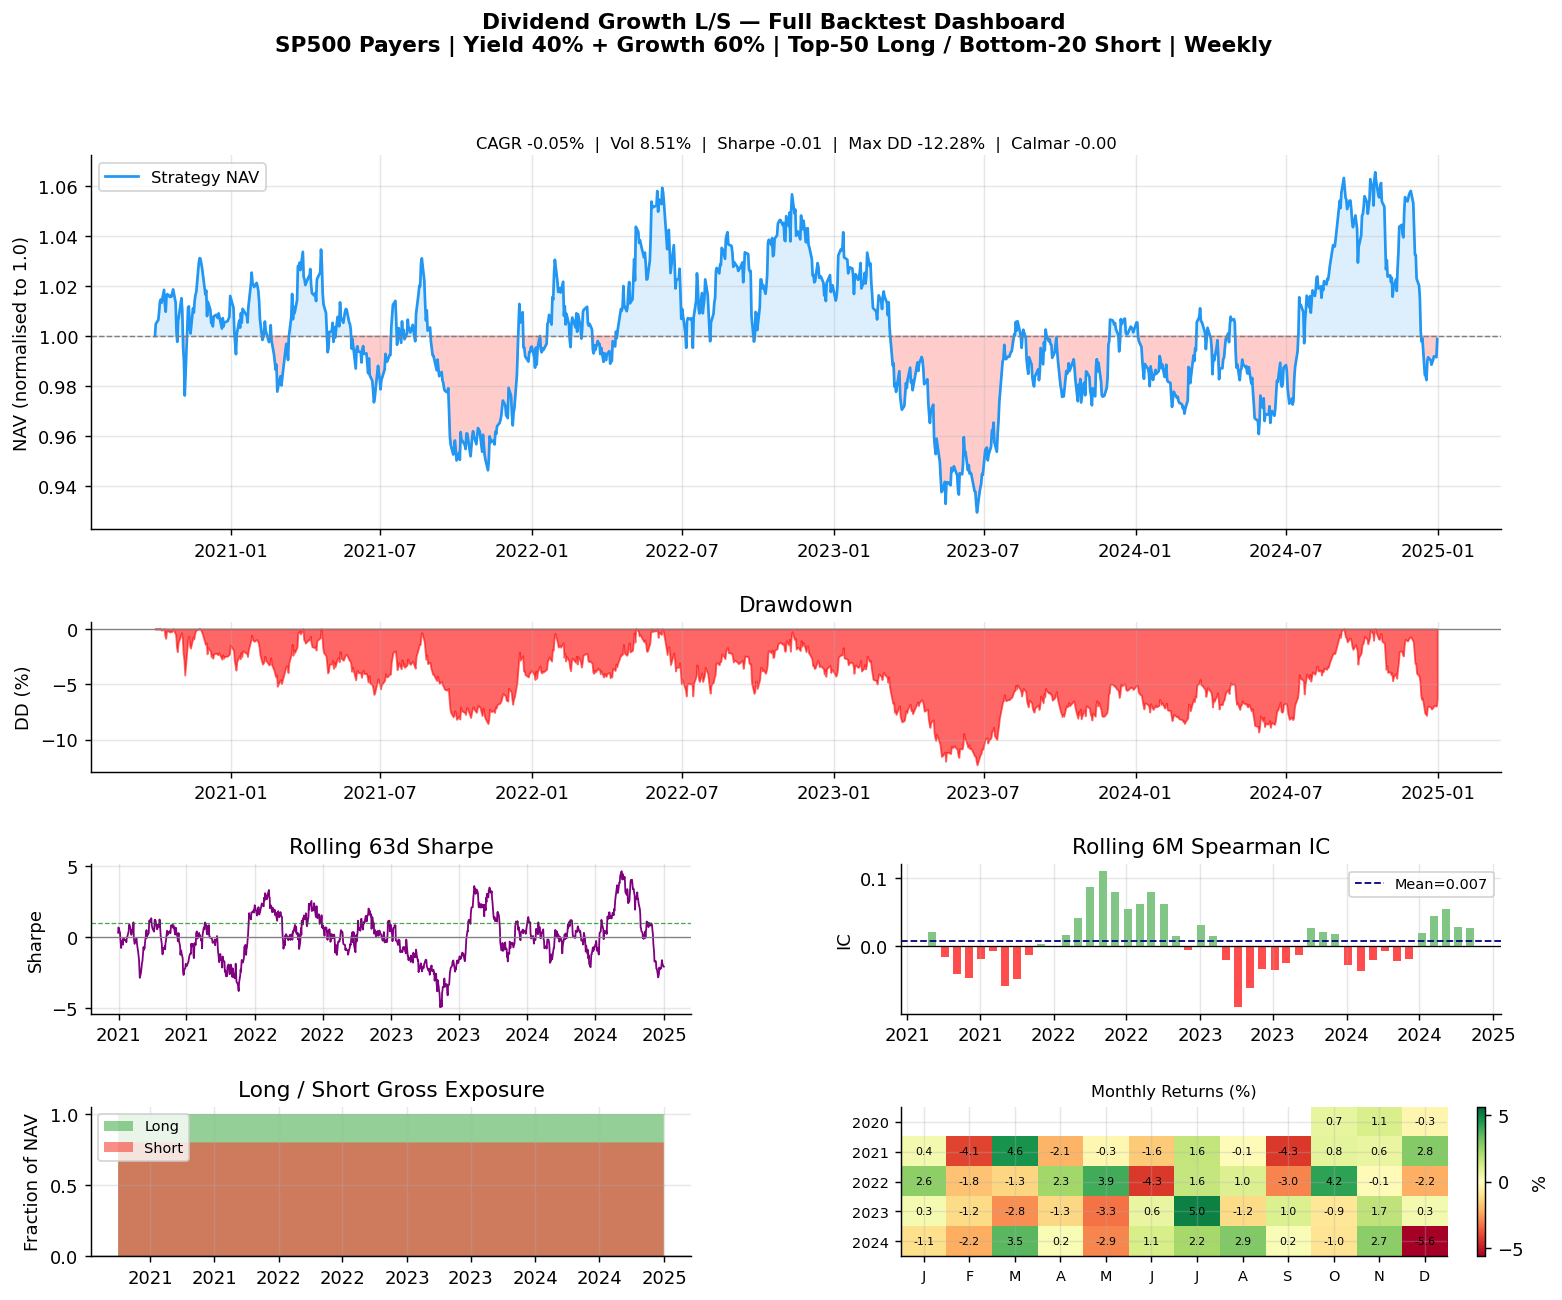

Dashboard saved to outputs/dividend_growth_ls/full_dashboard.png


In [ ]:
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35,
                        height_ratios=[2.5, 1, 1, 1])
fig.suptitle(
    'Dividend Growth L/S — Full Backtest Dashboard\n'
    'SP500 Payers | Yield 40% + Growth 60% | Top-50 Long / Bottom-20 Short | Weekly',
    fontsize=12, fontweight='bold'
)

# ── 1. NAV (top, full width) ─────────────────────────────────────────────────
ax_nav = fig.add_subplot(gs[0, :])
ax_nav.plot(nav.index, nav.values, color='#2196F3', linewidth=1.5, label='Strategy NAV')
ax_nav.fill_between(nav.index, 1, nav.values,
                     where=nav.values >= 1, alpha=0.15, color='#2196F3')
ax_nav.fill_between(nav.index, 1, nav.values,
                     where=nav.values < 1, alpha=0.2, color='red')
ax_nav.axhline(1, color='grey', linewidth=0.8, linestyle='--')
kpi = (f'CAGR {ann_ret:.2%}  |  Vol {ann_vol:.2%}  |  Sharpe {sharpe:.2f}  |  '
       f'Max DD {max_dd:.2%}  |  Calmar {calmar:.2f}')
ax_nav.set_title(kpi, fontsize=9, pad=4)
ax_nav.set_ylabel('NAV (normalised to 1.0)')
ax_nav.legend(fontsize=9)
ax_nav.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ── 2. Drawdown ───────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, :])
ax_dd.fill_between(dd.index, dd.values * 100, 0, color='red', alpha=0.6)
ax_dd.axhline(0, color='grey', linewidth=0.7)
ax_dd.set_ylabel('DD (%)')
ax_dd.set_title('Drawdown')
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ── 3. Rolling Sharpe (63d) ───────────────────────────────────────────────────
ax_rs = fig.add_subplot(gs[2, 0])
rolling_sharpe = (daily_ret.rolling(63).mean() / daily_ret.rolling(63).std()) * np.sqrt(252)
ax_rs.plot(rolling_sharpe.index, rolling_sharpe.values, color='purple', linewidth=1)
ax_rs.axhline(0, color='grey', linewidth=0.7)
ax_rs.axhline(1, color='green', linewidth=0.7, linestyle='--', alpha=0.7)
ax_rs.set_title('Rolling 63d Sharpe')
ax_rs.set_ylabel('Sharpe')
ax_rs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 4. Rolling IC ─────────────────────────────────────────────────────────────
ax_ic = fig.add_subplot(gs[2, 1])
ic_ts = ic_series.reindex(active_eq.index, method='ffill')
rolling_ic = ic_series.rolling(6).mean()
ic_colors = ['#4CAF50' if v >= 0 else 'red' for v in rolling_ic.values]
ax_ic.bar(rolling_ic.index, rolling_ic.values, color=ic_colors, alpha=0.7, width=20)
ax_ic.axhline(0, color='black', linewidth=0.7)
ax_ic.axhline(ic_series.mean(), color='navy', linestyle='--', linewidth=1,
              label=f'Mean={ic_series.mean():.3f}')
ax_ic.set_title('Rolling 6M Spearman IC')
ax_ic.set_ylabel('IC')
ax_ic.legend(fontsize=8)
ax_ic.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 5. Long vs Short exposure (normalised by equity) ─────────────────────────
ax_exp = fig.add_subplot(gs[3, 0])
long_exp_frac  =  active_eq['long_exposure']  / active_eq['equity']
short_exp_frac = -active_eq['short_exposure'] / active_eq['equity']
ax_exp.stackplot(active_eq.index, long_exp_frac.values,
                 colors=['#4CAF50'], alpha=0.6, labels=['Long'])
ax_exp.stackplot(active_eq.index, short_exp_frac.values,
                 colors=['#f44336'], alpha=0.6, labels=['Short'])
ax_exp.axhline(0, color='black', linewidth=0.7)
ax_exp.set_title('Long / Short Gross Exposure')
ax_exp.set_ylabel('Fraction of NAV')
ax_exp.legend(fontsize=8, loc='upper left')
ax_exp.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 6. Monthly return heatmap ─────────────────────────────────────────────────
ax_mth = fig.add_subplot(gs[3, 1])
monthly_ret = daily_ret.resample('ME').apply(lambda x: (1+x).prod()-1)
monthly_ret.index = monthly_ret.index.to_period('M')
mth_table = monthly_ret.to_frame('ret')
mth_table['year']  = monthly_ret.index.year
mth_table['month'] = monthly_ret.index.month
pivot = mth_table.pivot(index='year', columns='month', values='ret')
vmax = np.abs(pivot.values[~np.isnan(pivot.values)]).max()
im = ax_mth.imshow(pivot.values * 100, cmap='RdYlGn', aspect='auto',
                   vmin=-vmax*100, vmax=vmax*100)
ax_mth.set_yticks(range(len(pivot.index)))
ax_mth.set_yticklabels(pivot.index, fontsize=8)
ax_mth.set_xticks(range(12))
ax_mth.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
ax_mth.set_title('Monthly Returns (%)', fontsize=9)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax_mth.text(j, i, f'{v*100:.1f}', ha='center', va='center',
                        fontsize=6, color='black')
plt.colorbar(im, ax=ax_mth, fraction=0.04, label='%')

plt.savefig(f'{ATTEMPT}/outputs/full_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Dashboard saved to {ATTEMPT}/outputs/full_dashboard.png')

---
## 5 — Top Holdings Snapshot

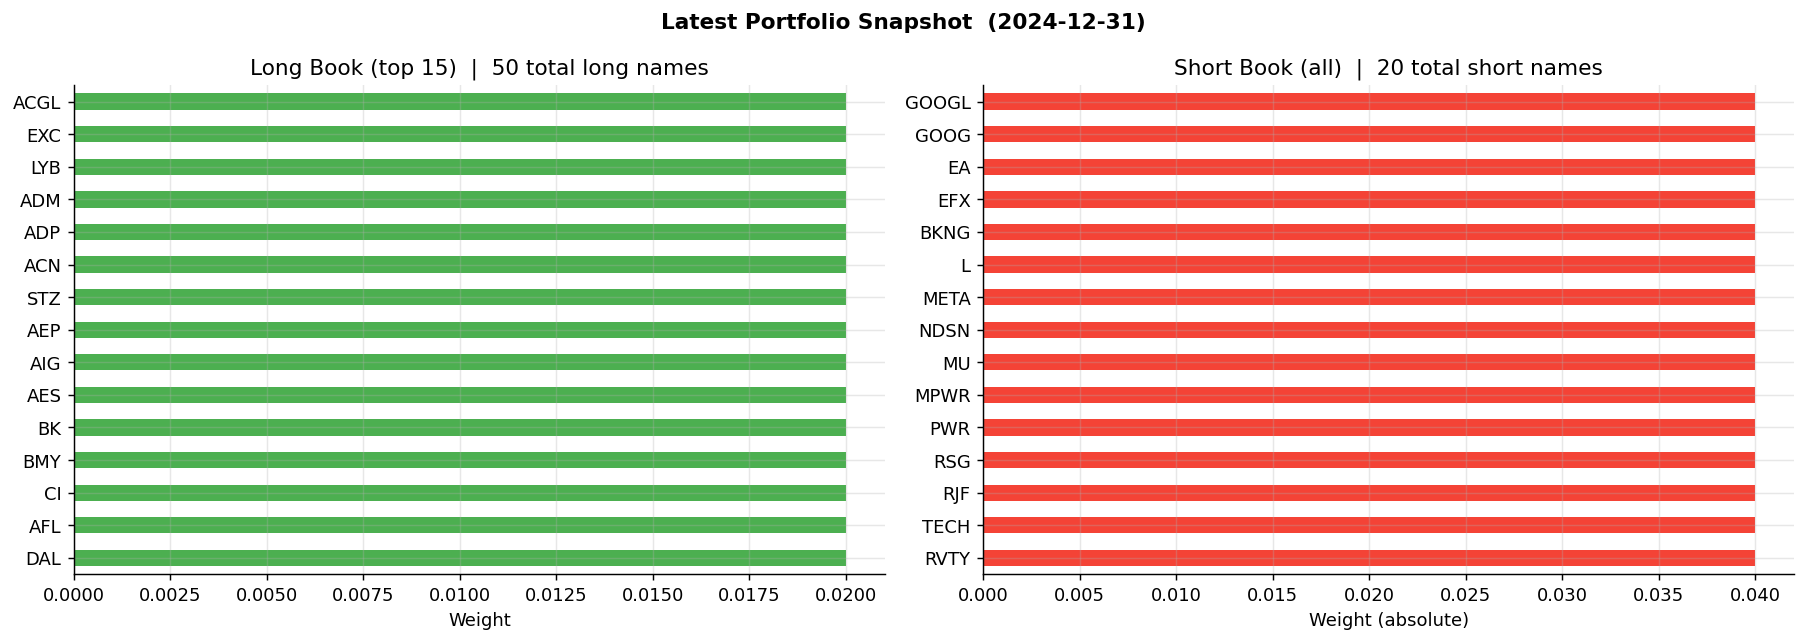


--- Long names ---
ACGL    0.020006
EXC     0.020006
LYB     0.020006
ADM     0.020006
ADP     0.020006
ACN     0.020006
STZ     0.020006
AEP     0.020006
AIG     0.020006
AES     0.020006
BK      0.020006
BMY     0.020006
CI      0.020006
AFL     0.020006
DAL     0.020006

--- Short names ---
GOOGL    0.040012
GOOG     0.040012
EA       0.040012
EFX      0.040012
BKNG     0.040012
L        0.040012
META     0.040012
NDSN     0.040012
MU       0.040012
MPWR     0.040012
PWR      0.040012
RSG      0.040012
RJF      0.040012
TECH     0.040012
RVTY     0.040012


In [10]:
# Latest weights
latest_date = wts.index[-1]
latest_wts  = wts.loc[latest_date].dropna()
latest_wts  = latest_wts[latest_wts.abs() > 1e-4].sort_values(ascending=False)

long_names  = latest_wts[latest_wts > 0].head(15)
short_names = latest_wts[latest_wts < 0].tail(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Latest Portfolio Snapshot  ({latest_date.date()})', fontsize=12, fontweight='bold')

ax = axes[0]
long_names.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title(f'Long Book (top 15)  |  {len(latest_wts[latest_wts > 0])} total long names')
ax.set_xlabel('Weight')
ax.invert_yaxis()

ax = axes[1]
short_names.abs().plot(kind='barh', ax=ax, color='#f44336')
ax.set_title(f'Short Book (all)  |  {len(latest_wts[latest_wts < 0])} total short names')
ax.set_xlabel('Weight (absolute)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print('\n--- Long names ---')
print(long_names.to_string())
print('\n--- Short names ---')
print(short_names.abs().to_string())

---
## 6 — Signal Spread: Top-10% vs Bottom-10% Cumulative Return

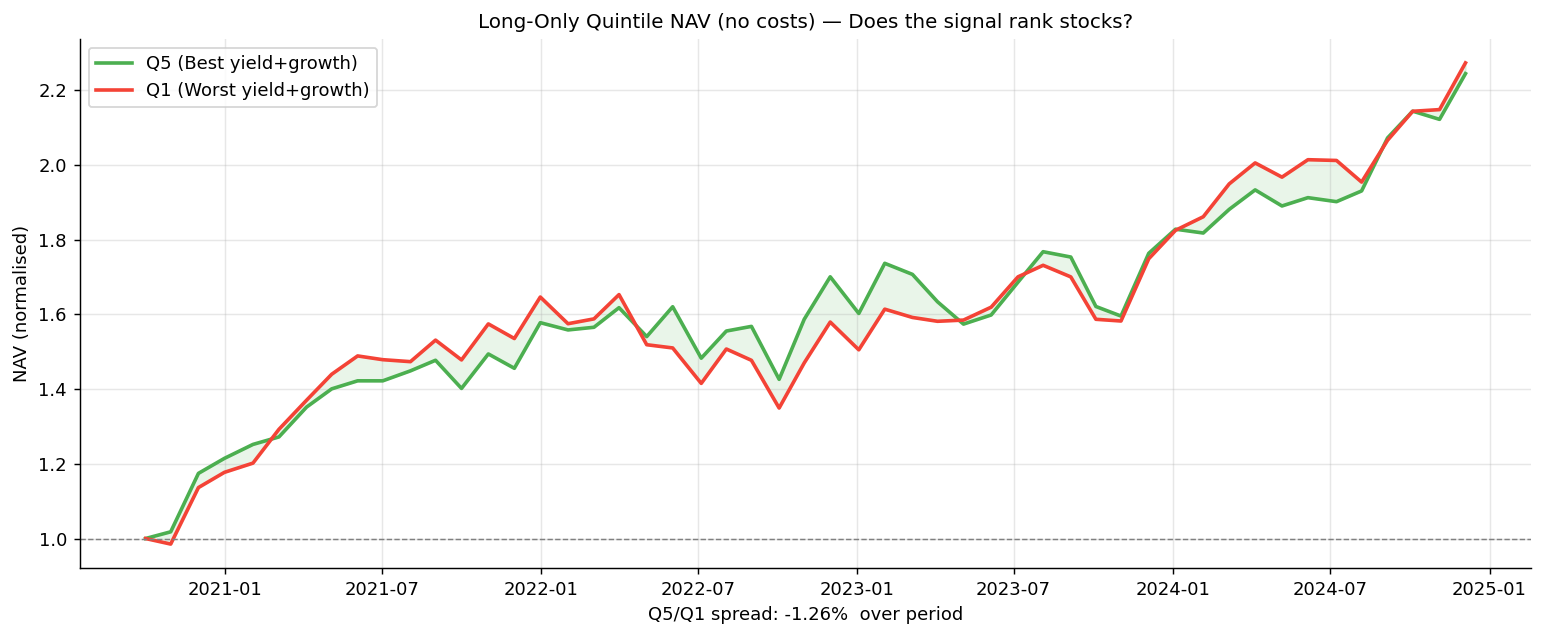

Q5 total return: 124.43%
Q1 total return: 127.30%
Spread (Q5-Q1):  -1.26%


In [11]:
# Simulate simple equal-weight quintile portfolios (no costs) for signal validity check
# Rebalance monthly, long-only, to isolate the signal from execution

comp_active  = composite.loc[(composite.index >= start_trade) & (composite.index <= end_trade)]
close_active = close.loc[(close.index >= start_trade) & (close.index <= end_trade)]
daily_rets   = close_active.pct_change()

q_nav = {1: [1.0], 5: [1.0]}
q_dates = [comp_active.index[0]]

rebal_every = 21
for i in range(rebal_every, len(comp_active), rebal_every):
    signal_date = comp_active.index[i - rebal_every]
    hold_slice  = daily_rets.iloc[i - rebal_every: i]
    scores = comp_active.loc[signal_date].dropna()
    if len(scores) < 20:
        continue
    q = pd.qcut(scores, 5, labels=False) + 1
    for qi in [1, 5]:
        members = q[q == qi].index
        period_ret = hold_slice[members].mean(axis=1)
        cum = (1 + period_ret).prod()
        q_nav[qi].append(q_nav[qi][-1] * cum)
    q_dates.append(comp_active.index[min(i, len(comp_active)-1)])

q5_nav = pd.Series(q_nav[5][:len(q_dates)], index=q_dates)
q1_nav = pd.Series(q_nav[1][:len(q_dates)], index=q_dates)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(q5_nav.index, q5_nav.values, color='#4CAF50', linewidth=2, label='Q5 (Best yield+growth)')
ax.plot(q1_nav.index, q1_nav.values, color='#f44336', linewidth=2, label='Q1 (Worst yield+growth)')
ax.fill_between(q5_nav.index, q5_nav.values, q1_nav.reindex(q5_nav.index, method='ffill').values,
                alpha=0.12, color='#4CAF50')
ax.axhline(1, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Long-Only Quintile NAV (no costs) — Does the signal rank stocks?', fontsize=11)
ax.set_ylabel('NAV (normalised)')
ax.legend(fontsize=10)
spread = (q5_nav.iloc[-1] / q1_nav.iloc[-1] - 1)
ax.set_xlabel(f'Q5/Q1 spread: {spread:.2%}  over period')
plt.tight_layout()
plt.show()

print(f'Q5 total return: {q5_nav.iloc[-1]-1:.2%}')
print(f'Q1 total return: {q1_nav.iloc[-1]-1:.2%}')
print(f'Spread (Q5-Q1):  {spread:.2%}')

---
## 7 — Next Steps

| Idea | Expected Impact |
|------|-----------------|
| **Short dividend-cutters instead of bottom-payers** | Stronger short alpha — cuts precede earnings deterioration |
| **Add sector-neutral ranking** | Remove sector rotation noise (Utilities vs Tech) |
| **Combine with 6M momentum** | Dividend growers + positive momentum = "compounder" screen |
| **Extend lookback** | YoY growth → 3Y CAGR for more stability |

Re-run backtest after modifying `strategies/dividend_growth_ls.py` and rebuilding signal via `scripts/build_div_signals.py`.